# Visualização de Dados com Python

Neste notebook vamos trabalhar com o dataset **br_inmet_bdmep_estacao_csv.gz** para praticar:

- leitura de dados com Pandas
- exploração inicial da estrutura
- criação de indicadores e agrupamentos
- visualização com **Pandas Plot**
- visualização com **Matplotlib**
- visualização com **Seaborn**

O objetivo é entender como os gráficos ajudam na análise exploratória de dados (EDA) de uma rede de estações meteorológicas.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

# Configurações visuais globais
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

## 1. Leitura do arquivo

Carregamos o dataset comprimido diretamente com Pandas — sem necessidade de descompactar manualmente.  
Ajuste `CAMINHO_ARQUIVO` se o arquivo estiver em outra pasta.

In [6]:
CAMINHO_ARQUIVO = r'C:\Users\berna\Downloads\br_inmet_bdmep_estacao.csv.gz'

df = pd.read_csv(CAMINHO_ARQUIVO, compression="gzip")
print("Dataset carregado com sucesso!")
print(f"Linhas: {df.shape[0]}  |  Colunas: {df.shape[1]}")
df.head()

Dataset carregado com sucesso!
Linhas: 612  |  Colunas: 7


,id_municipio,id_estacao,estacao,data_fundacao,latitude,longitude,altitude
0,5300108.0,A001,Brasilia,2000-05-07,-15.789444,-47.925833,1160.96
1,5300108.0,A042,Brazlandia,2017-07-19,-15.599722,-48.131111,1143.00
2,5300108.0,A045,Aguas Emendadas,2008-10-03,-15.596491,-47.625801,1030.36
3,5300108.0,A046,Gama (Ponte Alta),2014-10-01,-15.935278,-48.137500,990.00
4,5300108.0,A047,Paranoa (Coopa-Df),2017-02-07,-16.012222,-47.557417,1043.00


## 2. Conhecendo a estrutura dos dados

Antes de criar gráficos, precisamos entender como os dados estão organizados.

In [7]:
print("Quantidade de linhas e colunas:")
print(df.shape)

print("\nNomes das colunas:")
print(df.columns.tolist())

print("\nInformações gerais:")
df.info()

Quantidade de linhas e colunas:
(612, 7)

Nomes das colunas:
['id_municipio', 'id_estacao', 'estacao', 'data_fundacao', 'latitude', 'longitude', 'altitude']

Informações gerais:
<class 'pandas.DataFrame'>
RangeIndex: 612 entries, 0 to 611
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id_municipio   610 non-null    float64
 1   id_estacao     612 non-null    str    
 2   estacao        612 non-null    str    
 3   data_fundacao  612 non-null    str    
 4   latitude       612 non-null    float64
 5   longitude      612 non-null    float64
 6   altitude       595 non-null    float64
dtypes: float64(4), str(3)
memory usage: 33.6 KB


## 3. Ajustando tipos de dados

Convertemos a coluna de data e criamos variáveis derivadas úteis para as análises.

In [8]:
df["data_fundacao"] = pd.to_datetime(df["data_fundacao"], errors="coerce")
df["ano_fundacao"]  = df["data_fundacao"].dt.year

df["tipo_estacao"] = df["id_estacao"].str[0].map({
    "A": "Automática",
    "S": "Semiautomática",
    "B": "Boia",
}).fillna("Outro")

df["macrorregiao"] = pd.cut(
    df["latitude"],
    bins=[-90, -25, -15, -5, 5],
    labels=[
        "Sul/Sudeste (< -25°)",
        "Centro-Oeste (-25° a -15°)",
        "Nordeste/Norte (-15° a -5°)",
        "Extremo Norte (> -5°)"
    ]
)

print("Tipos após conversão:")
print(df.dtypes)

Tipos após conversão:
id_municipio            float64
id_estacao                  str
estacao                     str
data_fundacao    datetime64[us]
latitude                float64
longitude               float64
altitude                float64
ano_fundacao              int32
tipo_estacao                str
macrorregiao           category
dtype: object


## 4. Estatísticas básicas

Observamos as principais estatísticas das colunas numéricas.

In [9]:
df.describe()

,id_municipio,data_fundacao,latitude,longitude,altitude,ano_fundacao
count,6.100000e+02,612,612.000000,612.000000,595.000000,612.000000
mean,3.282992e+06,2009-08-31 07:10:35.294117,-15.709950,-48.400933,417.517782,2009.127451
min,1.100023e+06,2000-05-07 00:00:00,-84.000000,-79.494167,1.000000,2000.000000
25%,2.307208e+06,2006-12-20 00:00:00,-22.251555,-52.939767,131.060000,2006.000000
50%,3.156956e+06,2008-03-26 12:00:00,-16.124167,-48.228333,365.790000,2008.000000
75%,4.303831e+06,2011-12-19 00:00:00,-8.649722,-42.788472,629.445000,2011.250000
max,5.300108e+06,2020-12-18 00:00:00,4.477500,-29.345904,2450.000000,2020.000000
std,1.226355e+06,NaN,8.752006,7.373967,345.548799,4.666638


In [10]:
print("Distribuição por tipo de estação:")
print(df["tipo_estacao"].value_counts())

print("\nEstações por macro-região:")
print(df["macrorregiao"].value_counts())

Distribuição por tipo de estação:
tipo_estacao
Automática        573
Semiautomática     34
Boia                3
Outro               2
Name: count, dtype: int64

Estações por macro-região:
macrorregiao
Centro-Oeste (-25° a -15°)     250
Nordeste/Norte (-15° a -5°)    205
Sul/Sudeste (< -25°)            82
Extremo Norte (> -5°)           75
Name: count, dtype: int64


## 5. Gráfico 1 – Expansão da rede ao longo do tempo

Visualizamos quantas estações foram inauguradas a cada ano e o crescimento acumulado da rede.

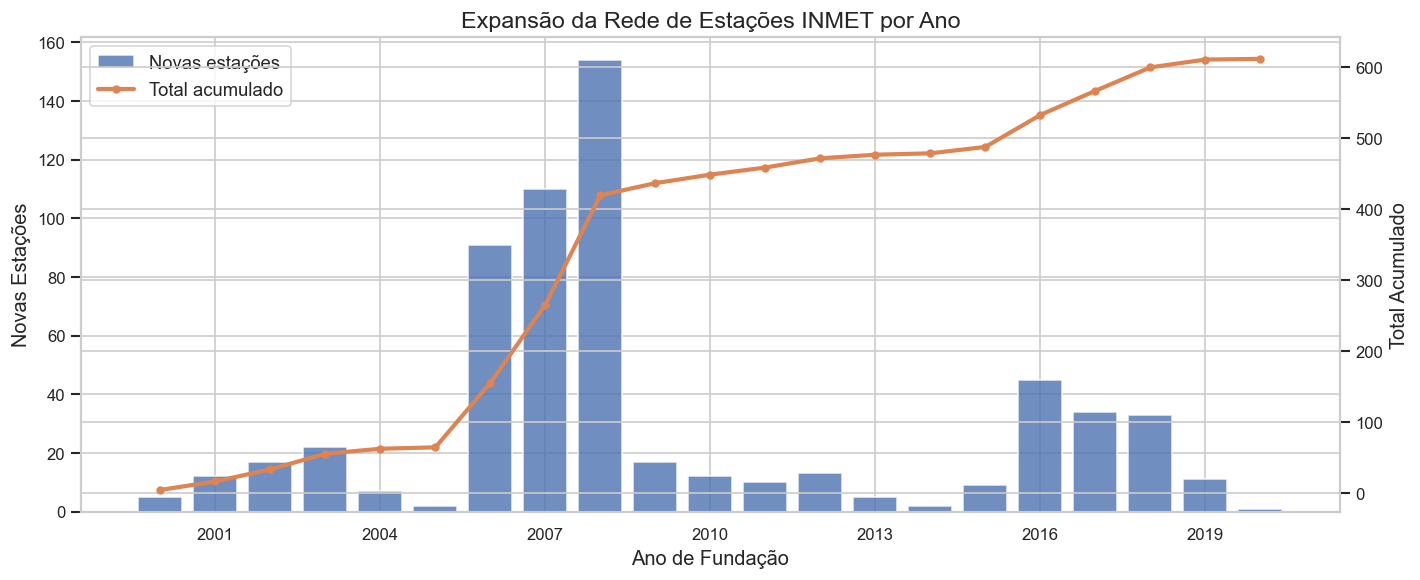

In [11]:
estacoes_por_ano = df["ano_fundacao"].value_counts().sort_index()
acumulado        = estacoes_por_ano.cumsum()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(estacoes_por_ano.index, estacoes_por_ano.values,
        color="#4C72B0", alpha=0.8, label="Novas estações")
ax2.plot(acumulado.index, acumulado.values,
         color="#DD8452", linewidth=2.5, marker="o", markersize=4,
         label="Total acumulado")

ax1.set_title("Expansão da Rede de Estações INMET por Ano")
ax1.set_xlabel("Ano de Fundação")
ax1.set_ylabel("Novas Estações")
ax2.set_ylabel("Total Acumulado")
ax1.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

## 6. Gráfico 2 – Distribuição de altitude

O histograma mostra como a altitude varia entre as estações, com a linha tracejada indicando a mediana.

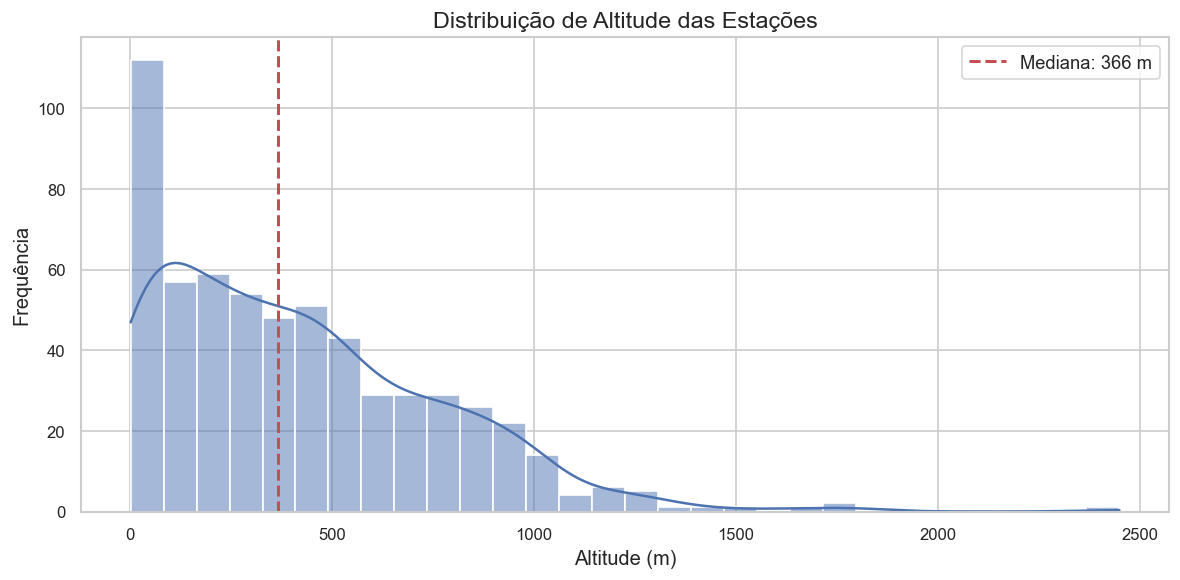

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(df["altitude"].dropna(), bins=30, kde=True,
             color="#4C72B0", ax=ax)

ax.axvline(df["altitude"].median(), color="#C44E52", linestyle="--",
           linewidth=1.8, label=f"Mediana: {df['altitude'].median():.0f} m")

ax.set_title("Distribuição de Altitude das Estações")
ax.set_xlabel("Altitude (m)")
ax.set_ylabel("Frequência")
ax.legend()

plt.tight_layout()
plt.show()

## 7. Gráfico 3 – Altitude por tipo de estação

O boxplot ajuda a comparar a dispersão e os valores extremos de altitude entre os diferentes tipos de estação.

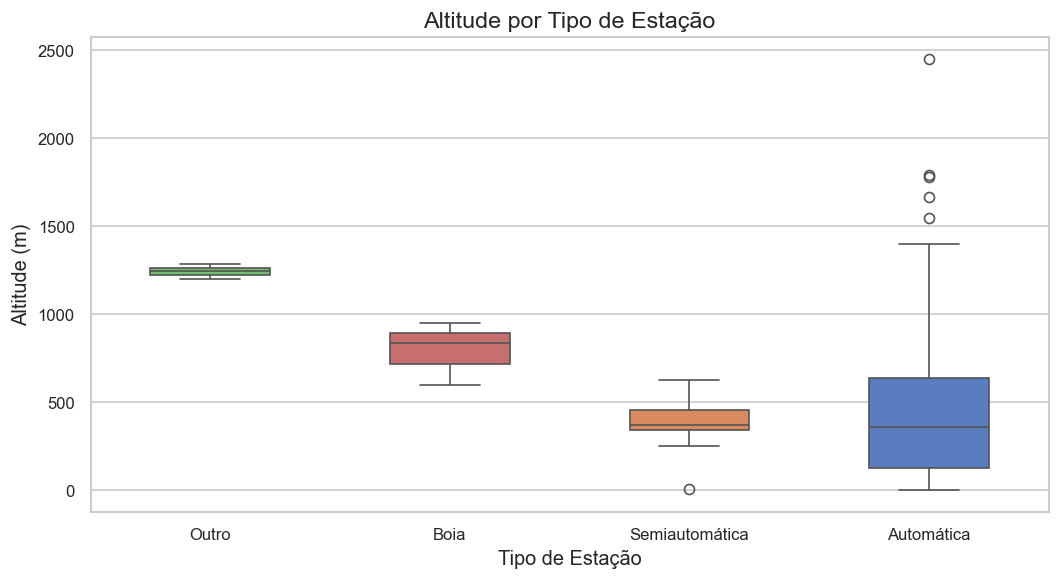

In [13]:
ordem = df.groupby("tipo_estacao")["altitude"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(9, 5))

sns.boxplot(data=df, x="tipo_estacao", y="altitude", order=ordem,
            hue="tipo_estacao", palette="muted", width=0.5, legend=False, ax=ax)

ax.set_title("Altitude por Tipo de Estação")
ax.set_xlabel("Tipo de Estação")
ax.set_ylabel("Altitude (m)")

plt.tight_layout()
plt.show()

## 8. Gráfico 4 – Composição da rede por tipo

Verificamos a proporção de cada tipo de estação na rede INMET.

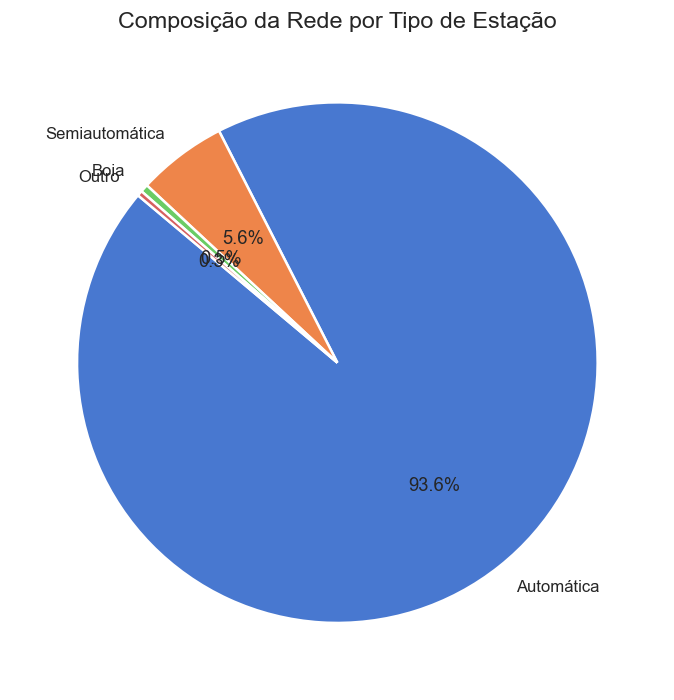

In [14]:
contagem_tipo = df["tipo_estacao"].value_counts()

fig, ax = plt.subplots(figsize=(7, 6))
wedges, texts, autotexts = ax.pie(
    contagem_tipo,
    labels=contagem_tipo.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("muted", len(contagem_tipo)),
    wedgeprops=dict(edgecolor="white", linewidth=1.5),
)
for at in autotexts:
    at.set_fontsize(11)

ax.set_title("Composição da Rede por Tipo de Estação")
plt.tight_layout()
plt.show()

## 9. Gráfico 5 – Latitude × Altitude (scatter)

Esse gráfico mostra como altitude e latitude se relacionam geograficamente, com a cor representando a longitude.

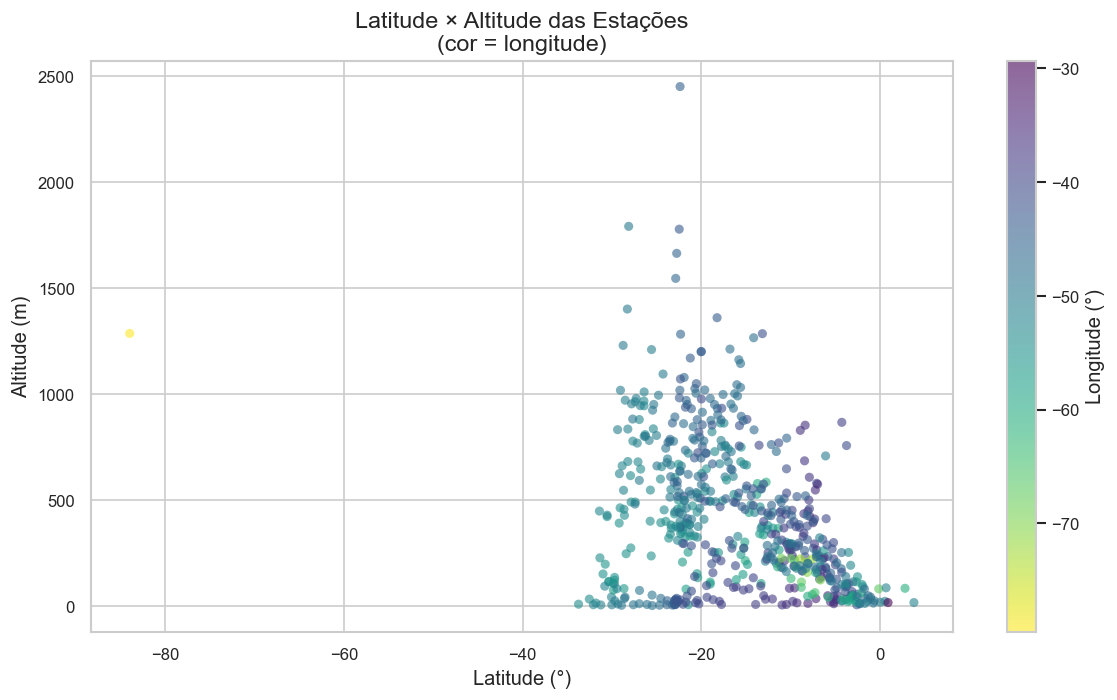

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    df["latitude"], df["altitude"],
    c=df["longitude"], cmap="viridis_r",
    alpha=0.6, s=30, edgecolors="none"
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Longitude (°)")

ax.set_title("Latitude × Altitude das Estações\n(cor = longitude)")
ax.set_xlabel("Latitude (°)")
ax.set_ylabel("Altitude (m)")

plt.tight_layout()
plt.show()

## 10. Gráfico 6 – Mapa geográfico das estações

Plotamos a posição geográfica de todas as estações, usando a altitude como cor e destacando as estações do Distrito Federal.

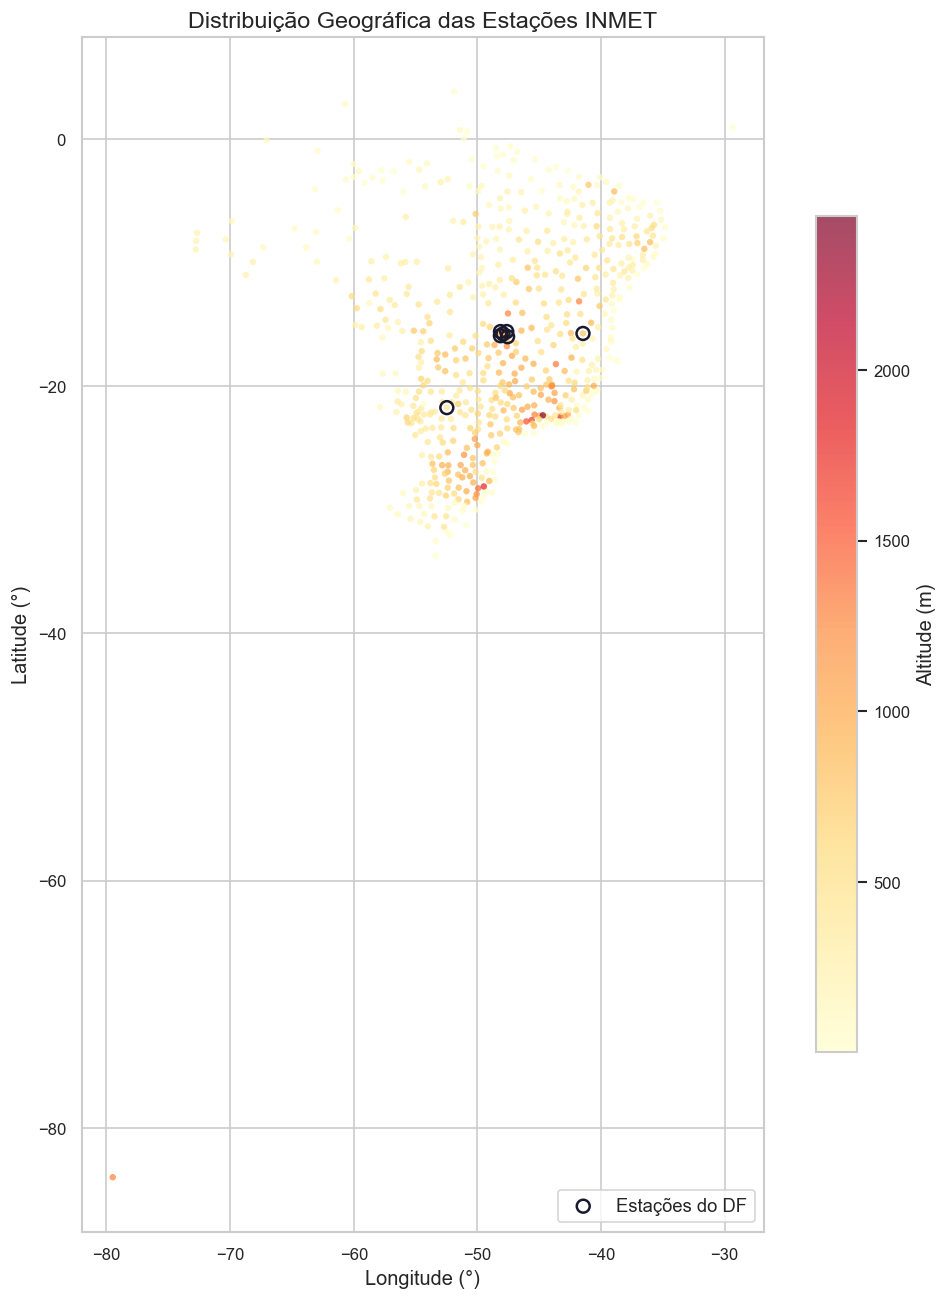

In [16]:
fig, ax = plt.subplots(figsize=(9, 11))

sc = ax.scatter(
    df["longitude"], df["latitude"],
    c=df["altitude"], cmap="YlOrRd",
    alpha=0.7, s=15, edgecolors="none"
)
cbar = plt.colorbar(sc, ax=ax, shrink=0.7)
cbar.set_label("Altitude (m)")

bsb = df[df["estacao"].str.contains("Brasilia|Brazlandia|Gama|Paranoa|Aguas", case=False, na=False)]
ax.scatter(bsb["longitude"], bsb["latitude"],
           s=60, facecolors="none", edgecolors="#1a1a2e", linewidths=1.5,
           label="Estações do DF")
ax.legend(loc="lower right")

ax.set_title("Distribuição Geográfica das Estações INMET")
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

## 11. Gráfico 7 – Estações por macro-região

Comparamos quantas estações existem em cada macro-região do Brasil, agrupadas por faixas de latitude.

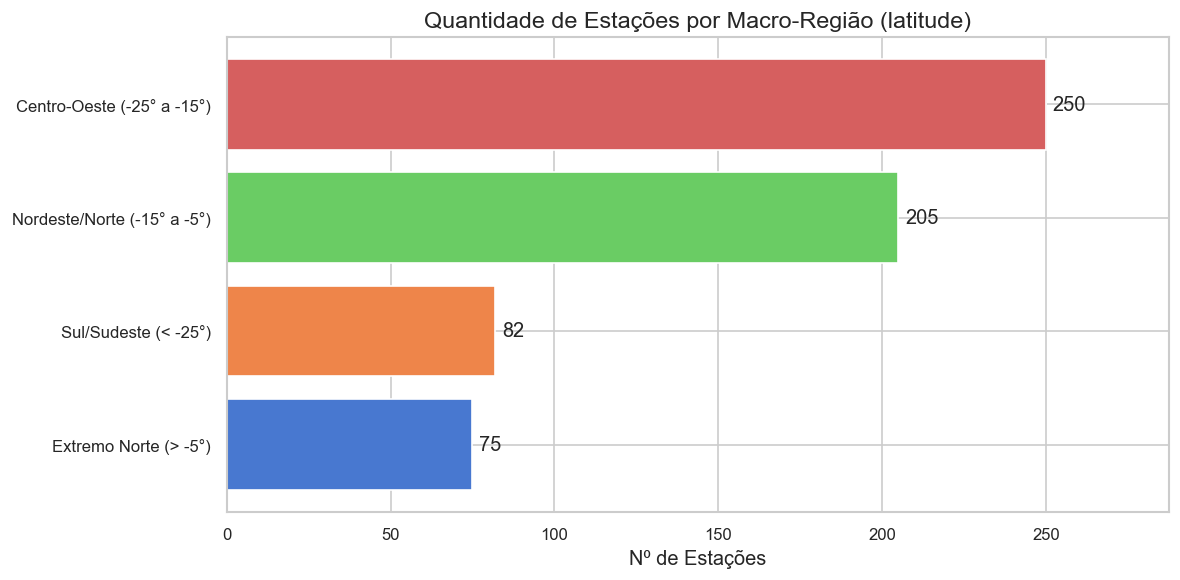

In [17]:
contagem_regiao = df["macrorregiao"].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(contagem_regiao.index, contagem_regiao.values,
               color=sns.color_palette("muted", len(contagem_regiao)))
ax.bar_label(bars, padding=4)
ax.set_title("Quantidade de Estações por Macro-Região (latitude)")
ax.set_xlabel("Nº de Estações")
ax.set_xlim(0, contagem_regiao.max() * 1.15)

plt.tight_layout()
plt.show()

## 12. Gráfico 8 – Altitude mediana por período de instalação

Analisamos se o perfil altimétrico das estações mudou ao longo dos períodos de expansão da rede.

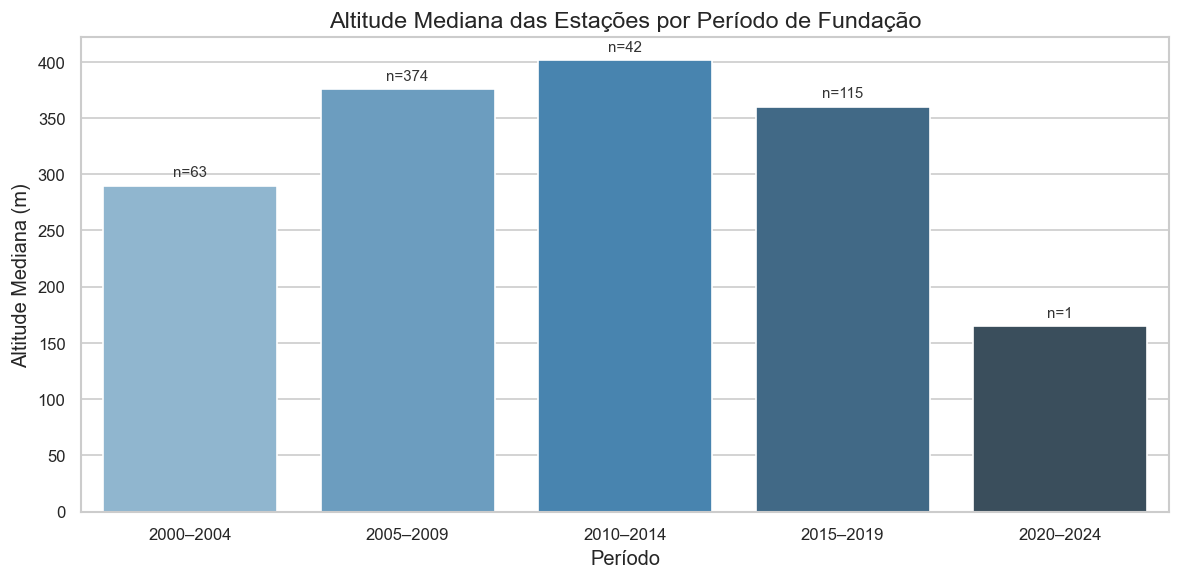

In [18]:
df["periodo"] = (df["ano_fundacao"] // 5 * 5).astype("Int64").astype(str) + "–" +                ((df["ano_fundacao"] // 5 * 5) + 4).astype("Int64").astype(str)

media_alt = (
    df.dropna(subset=["altitude", "ano_fundacao"])
    .groupby("periodo")["altitude"]
    .agg(["median", "count"])
    .reset_index()
    .sort_values("periodo")
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=media_alt, x="periodo", y="median",
            hue="periodo", palette="Blues_d", legend=False, ax=ax)

for i, row in enumerate(media_alt.itertuples()):
    ax.text(i, row.median + 8, f"n={int(row.count)}",
            ha="center", fontsize=9, color="#333")

ax.set_title("Altitude Mediana das Estações por Período de Fundação")
ax.set_xlabel("Período")
ax.set_ylabel("Altitude Mediana (m)")

plt.tight_layout()
plt.show()

## 13. Resumo final

Com este notebook foi possível:

- **Carregar** um dataset real comprimido (`.gz`) diretamente com Pandas
- **Explorar** a estrutura das 612 estações meteorológicas do INMET
- **Converter** tipos e criar variáveis derivadas (ano, tipo, macro-região, período)
- **Gerar estatísticas** descritivas das variáveis numéricas
- Criar **8 gráficos** diferentes cobrindo:
  - Evolução temporal (barras + linha acumulada)
  - Distribuições (histograma com KDE, boxplot)
  - Proporções (pizza)
  - Relações entre variáveis (scatter)
  - Distribuição geográfica (mapa por coordenadas)
  - Comparação de grupos (barras horizontais, barras com contagem)

> 💡 **Próximos passos sugeridos:** integrar shapefile do Brasil para um mapa coroplético real, cruzar com dados climáticos de cada estação, ou filtrar por estado usando o código `id_municipio`.